linear regression

Index(['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer',
       'coarse_aggregate', 'fine_aggregate ', 'age',
       'concrete_compressive_strength'],
      dtype='str')
1030 xsize
1030 ysize


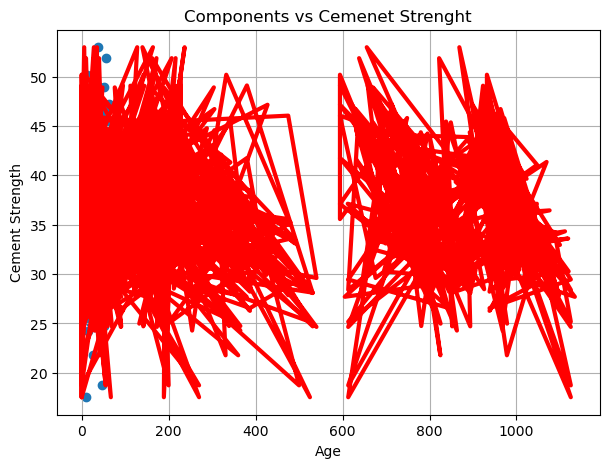

Mean Squared Error: 236.34456655245594
Mean Absolute Error: 12.440766262056659
R2 Score: 0.08278711936331362


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv("concrete_data.csv")

df = df.dropna()


X = df.iloc[::-1]
y = df.iloc[:,-1]


print(X.columns)

print(len(X),"xsize")
print(len(y),"ysize")



x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

def eval(y_pred,y_test):
    #pred,Y_test, -> MSE, R2 score, rmse
    print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
    print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))


plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Age")
plt.ylabel("Cement Strength")
plt.plot(x_test, y_pred,color ="red",linewidth=3, label="Line of Best Fit")
plt.title("Components vs Cemenet Strenght")
plt.grid(True)
plt.show()

eval(y_pred,y_test)


Random Forest Regression

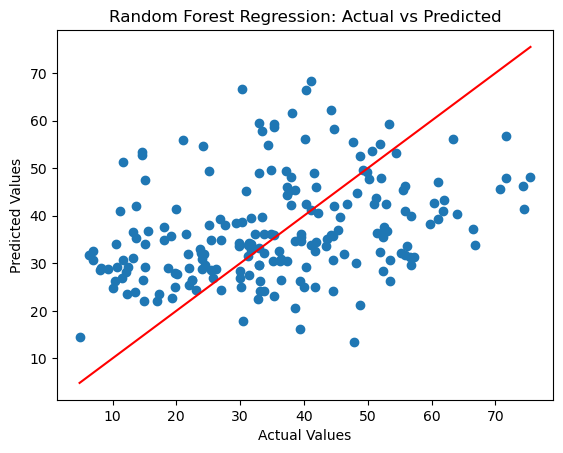

Mean Squared Error: 259.95534795595466
Mean Absolute Error: 13.12022066920943
R2 Score: -0.008842289093510924


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

df = pd.read_csv("concrete_data.csv")
df = df.dropna()

def eval(y_pred,y_test):
    #pred,Y_test, -> MSE, R2 score, rmse
    print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
    print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))

X = df.iloc[::-1]
y = df.iloc[:,-1]

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train,y_train)
y_pred =rf_model.predict(x_test)


plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regression: Actual vs Predicted")
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val],color="red")
plt.show()
eval(y_pred,y_test)

Polynomial Regression